This a correlation analysis of the key numerical features in the dataset related to tropical storms. The goal is to identify potential relationships between variables such as wind speed, pressure, damage, and other numerical features.

Loading the dataset csv into data frame and inspect the first few rows to understand its structure.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
dataset = pd.read_csv("completed_dataset_for_IS_project_25.csv")

print("From Dataset: Completed dataset")
print(dataset.head(10))

From Dataset: Completed dataset
   Year  MONTH  DAY   LAT  LONG  WIND_KTS  PRESSURE CAT  Shape_Leng Country  \
0  1880      8   11  23.0 -91.9        70         0  H1    0.806226  Mexico   
1  1880      8   11  23.4 -92.6        80         0  H1    0.761577  Mexico   
2  1880      8   11  23.7 -93.3        80         0  H1    0.583095  Mexico   
3  1880      8   12  24.0 -93.8        90         0  H2    0.670820  Mexico   
4  1880      9    6  23.9 -88.6        40         0  TS    0.360555  Mexico   
5  1880      8   10  22.0 -89.6        60         0  TS    0.854400  Mexico   
6  1880      8    9  21.0 -87.4        70         0  H1    0.761577  Mexico   
7  1880      8   10  21.3 -88.1        60         0  TS    0.854400  Mexico   
8  1880      8   10  21.6 -88.9        50         0  TS    0.806226  Mexico   
9  1880     10    6  21.4 -87.3        50         0  TS    0.800000  Mexico   

   ...   Jun   Jul   Aug   Sep   Oct   Nov   Dec  Storm Intensity  \
0  ... -0.21 -0.18 -0.11 -0.1

Before the analysis, we must check the basic summary statistics of the numerical columns to better understand the data distribution.

In [2]:
numeric_df = dataset.select_dtypes(include=['float64', 'int64'])

# Display basic statistics for numeric columns
numeric_df.describe()

,Year,MONTH,DAY,LAT,LONG,WIND_KTS,PRESSURE,Shape_Leng,CO2 emission (Tons),Jan,...,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Storm Intensity,Storm Intensity Label,Wind Speed Squared
count,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,5.265600e+04,52656.000000,...,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000
mean,1963.141826,8.501937,15.890022,23.642867,-86.212449,54.021137,392.746069,1.194504,3.681439e+10,0.116301,...,0.090699,0.102566,0.097883,0.099385,0.115567,0.109884,0.100033,65.655879,2.162868,3555.255261
std,35.909454,1.380465,8.802759,9.512564,36.878742,25.238544,485.291884,0.845690,8.179390e+10,0.359146,...,0.307962,0.285277,0.294818,0.293778,0.302885,0.315836,0.331759,58.122811,1.463169,3401.414306
min,1880.000000,1.000000,1.000000,4.200000,-180.000000,10.000000,0.000000,0.000000,0.000000e+00,-0.810000,...,-0.520000,-0.510000,-0.550000,-0.580000,-0.580000,-0.550000,-0.820000,0.000000,-2.000000,100.000000
25%,1941.000000,8.000000,8.000000,16.200000,-110.700000,35.000000,0.000000,0.700000,6.906640e+06,-0.150000,...,-0.140000,-0.110000,-0.130000,-0.120000,-0.080000,-0.080000,-0.140000,28.460520,1.000000,1225.000000
50%,1972.000000,9.000000,16.000000,21.300000,-84.600000,45.000000,0.000000,1.004988,2.648858e+09,0.080000,...,0.030000,0.040000,0.050000,0.060000,0.090000,0.050000,0.080000,48.466440,2.000000,2025.000000
75%,1992.000000,9.000000,23.000000,29.800000,-64.400000,70.000000,992.000000,1.421267,1.215048e+10,0.390000,...,0.370000,0.330000,0.350000,0.340000,0.330000,0.300000,0.380000,83.815250,3.000000,4900.000000
max,2008.000000,12.000000,31.000000,69.000000,180.000000,165.000000,1024.000000,11.180340,3.530000e+11,1.020000,...,0.770000,0.650000,0.710000,0.710000,0.750000,0.740000,0.790000,807.207520,7.000000,27225.000000


We'll now calculate the correlation matrix for the numeric columns in the dataset. This matrix will show pairwise correlation coefficients between different features.

In [4]:
# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

#Filter for strong correlations (absolute value > 0.6 and not self-correlation)
strong_corr = corr_matrix.unstack().reset_index()
strong_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Remove duplicates and self-correlations
strong_corr_filtered = strong_corr[
    (strong_corr['Feature 1'] != strong_corr['Feature 2']) &
    (strong_corr['Correlation'].abs() > 0.6)
].sort_values(by='Correlation', ascending=False)

strong_corr_filtered = strong_corr_filtered.drop_duplicates(subset=['Correlation'])
strong_corr_filtered

,Feature 1,Feature 2,Correlation
557,Wind Speed Squared,WIND_KTS,0.973863
374,Jul,Jun,0.957154
301,Apr,May,0.953519
426,Sep,Oct,0.951484
401,Aug,Sep,0.951267
...,...,...,...
438,Oct,PRESSURE,0.688928
462,Nov,PRESSURE,0.680923
164,PRESSURE,Dec,0.667776
222,Jan,PRESSURE,0.663077


To better understand the relationships between the features, we will create a heatmap of the correlation matrix. This will visually show the strength of correlations between variables.

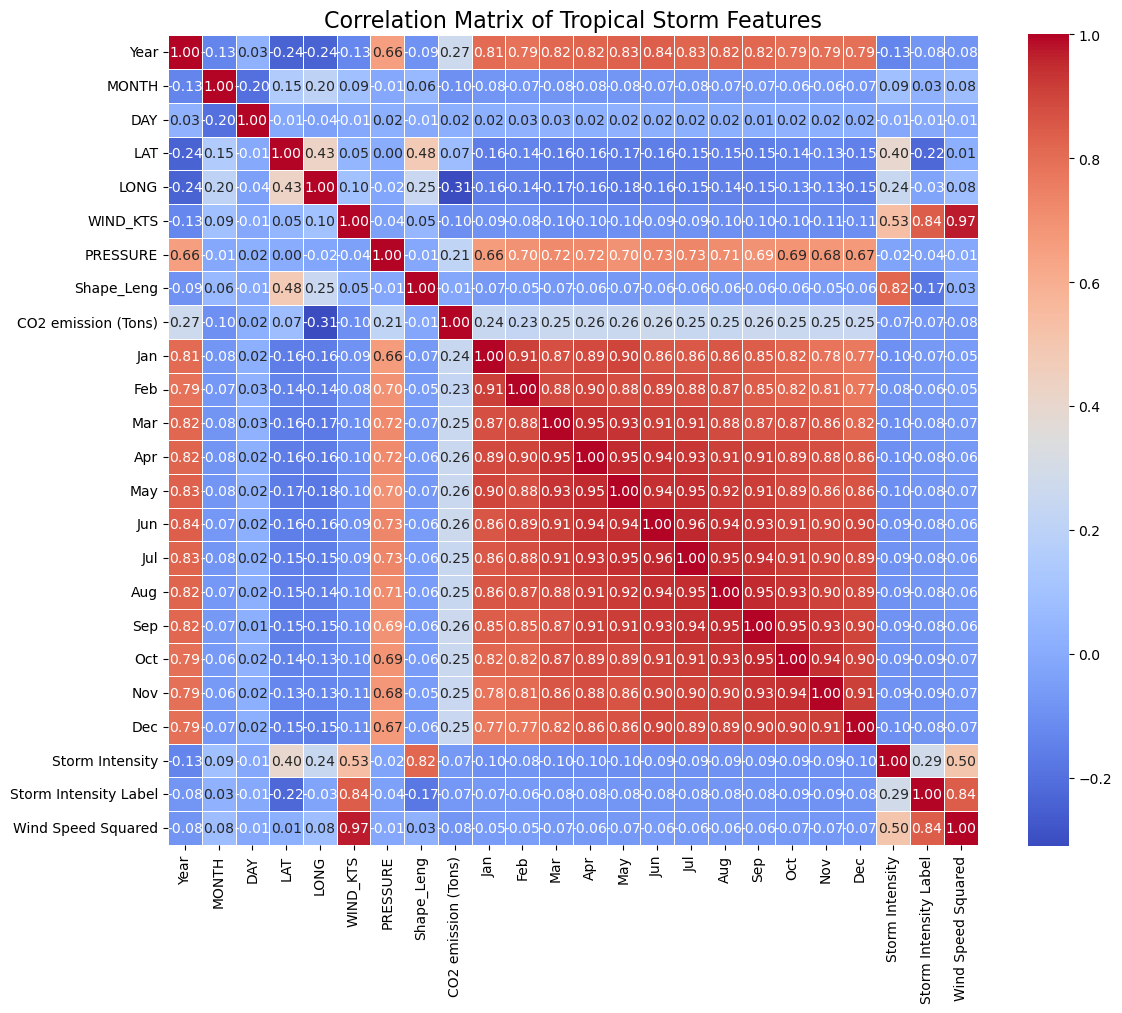

In [5]:
# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix of Tropical Storm Features", fontsize=16)
plt.tight_layout()

# Saving the heatmap as an image file
plt.savefig("correlation_matrix.png")

# Show the plot
plt.show()

**Correlation Analysis Interpretation**

Problem Statement Recap:  
This project aims to determine whether rising CO₂ emissions lead to higher global temperatures and increased likelihood of tropical storms, while identifying any other significant patterns or trends in the datasets.


Key Findings from the Correlation Heatmap:

1. Rising CO₂ Emissions and Global Temperatures
- CO₂ vs Monthly Temps (`Jan`–`Dec`): Correlations ≈ **0.25–0.27** (moderate positive)
- Year vs Monthly Temps: Correlations ≈ **0.79–0.84** (strong positive)
- Interpretation: There is a clear upward temperature trend across the years and a moderate positive correlation between CO₂ emissions and temperatures. This supports the hypothesis that CO₂ increases may be contributing to long-term warming.

2. Temperature and Tropical Storm Intensity
- WIND_KTS vs Storm Intensity Label: **0.84** (strong positive)
- WIND_KTS vs PRESSURE: **-0.77** (strong negative)
- Interpretation: Stronger storms tend to have lower pressure and higher wind speeds. The correlation between wind speed and storm intensity validates the use of `WIND_KTS` and `Wind Speed Squared` as storm severity indicators.

3. Engineered Feature: Wind Speed Squared
- WIND_KTS vs Wind Speed Squared: **0.97** (very strong positive)
- Wind Speed Squared vs Storm Intensity Label: **0.84** (strong positive)
- Interpretation: These strong correlations confirm the relevance of the engineered `Wind Speed Squared` feature and its strong alignment with storm severity, enhancing predictive power.

4. Limited Predictive Power of Some Features
- Variables like `LAT`, `LONG`, `DAY`, and `MONTH` show weak or negligible correlation with storm intensity and CO₂, indicating limited standalone value for prediction.


**Overall Interpretation in Relation to the Problem Statement:**
Rising Temperatures Over Time: The heatmap supports evidence of a warming trend, strongly correlated with increasing CO₂ emissions - aligning with climate science and our central hypothesis.

Storm Intensity Links: There is a moderate relationship between higher temperatures, CO₂ emissions, and storm severity indicators like WIND_KTS, PRESSURE, and Shape_Leng, suggesting that warming and emissions may be associated with stronger tropical storms.

Causality vs. Correlation: While correlation does not imply causation, these relationships offer a strong foundation for developing predictive models and investigating causal links.

Engineered Feature Validation:
The features Wind Speed Squared and Storm Intensity Label show meaningful correlations with other storm-related variables. This validates their inclusion - they are not only grounded in domain knowledge but also statistically relevant. Their presence is expected to enhance model performance in future predictive tasks.